# Einops Basics — Exercises

This notebook teaches einops fundamentals through deliberate practice. Each section has **one worked example** with explanation, followed by **exercises** where you fill in the einops call.

Replace `# YOUR CODE HERE` with the correct einops expression. Hover over hints or expand the details blocks if you get stuck.

## Setup

Images shape: (6, 96, 96, 3)


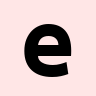

In [1]:
import numpy as np
from einops import rearrange, reduce, repeat
from utils import display_np_arrays_as_images, guess
display_np_arrays_as_images()

ims = np.load('resources/test_images.npy')
# ims shape: (6, 96, 96, 3) - 6 images, 96x96 pixels, 3 RGB channels
print(f"Images shape: {ims.shape}")
ims[0]  # display first image

---
## Section 1: Rearrange — Transposition

The simplest use of `rearrange` is **transposition**: reordering axes without changing any data.

The pattern `'h w c -> w h c'` says: "take an array with axes (height, width, channels) and return one with axes (width, height, channels)." This swaps the height and width of an image — a 90° rotation/transpose.

### Worked Example

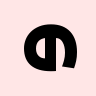

In [2]:
# Transpose the first image: swap height and width
# Input shape: (96, 96, 3) -> Output shape: (96, 96, 3)
# (looks different because rows become columns and vice versa)
rearrange(ims[0], 'h w c -> w h c')

### Exercise 1.1
Transpose the **3rd image** (index 2) — swap its height and width.

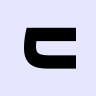

In [4]:
# YOUR CODE HERE
rearrange(ims[2], 'h w c -> w h c')

<details><summary>Answer</summary>

```python
rearrange(ims[2], 'h w c -> w h c')
```
</details>

### Exercise 1.2
**Prediction exercise:** What shape does `rearrange(ims[0], 'h w c -> w h c')` produce? Guess before running the cell below.

In [5]:
# First, make your prediction, then run this cell to check:
guess(rearrange(ims[0], 'h w c -> w h c').shape)

Answer is: (96, 96, 3) (hover to see)

<details><summary>Answer</summary>

The shape is `(96, 96, 3)` — same dimensions since the image is square. For a non-square image, width and height values would swap.
</details>

---
## Section 2: Rearrange — Composing Axes

**Composing axes** means merging multiple axes into one using parentheses on the **right** side of the arrow. The new axis length is the product of the composed axes.

For example, `'b h w c -> (b h) w c'` merges the batch axis (6) with the height axis (96) to create a single axis of length 6×96 = 576. Visually, this stacks all 6 images vertically into one tall image.

### Worked Example

In [ ]:
# Stack all 6 images vertically by composing batch into height
# (6, 96, 96, 3) -> (576, 96, 3)
rearrange(ims, 'b h w c -> (b h) w c')

### Exercise 2.1
Stack all 6 images **horizontally** — compose the batch dimension into the width dimension.

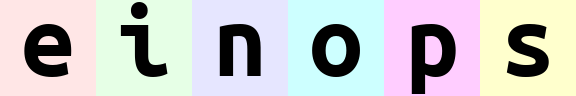

In [6]:
# YOUR CODE HERE
rearrange(ims, 'b h w c -> h (b w) c')

<details><summary>Answer</summary>

```python
rearrange(ims, 'b h w c -> h (b w) c')
```
</details>

### Exercise 2.2
Flatten a single image (`ims[0]`) into a **1D array** of shape `(27648,)` — that's 96 × 96 × 3.

Hint: compose all three axes into one.

In [8]:
# YOUR CODE HERE
rearrange(ims[0], 'h w c -> (h w c)')

array([1.        , 0.90196078, 0.90196078, ..., 1.        , 0.90196078,
       0.90196078], shape=(27648,))
<array of shape (27648,)>


<details><summary>Answer</summary>

```python
rearrange(ims[0], 'h w c -> (h w c)')
```
</details>

### Exercise 2.3
Stack the 6 images in a **2-row, 3-column grid**.

Hint: First decompose `b` into `(b1 b2)` with `b1=2` on the left side. Then compose `b1` with `h` (for rows) and `b2` with `w` (for columns).

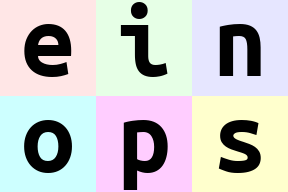

In [16]:
# YOUR CODE HERE

# I'm a bit confused about the split?
# how does b become (b1 b2) simply by saying b1=2?
rearrange(ims, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)

<details><summary>Answer</summary>

```python
rearrange(ims, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)
```
</details>

---
## Section 3: Rearrange — Decomposing Axes

**Decomposing axes** is the inverse of composing: split one axis into multiple axes using parentheses on the **left** side of the arrow. You must specify the size of all but one sub-axis so einops can compute the split.

For example, `'(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2` takes 6 images and decomposes the batch axis into 2×3. Then `b1` (2) is merged with height and `b2` (3) with width, producing a 2-row by 3-column grid.

### Worked Example

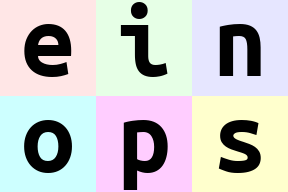

In [44]:
# Arrange 6 images in a 2x3 grid (2 rows, 3 columns)
# b=6 is decomposed into b1=2, b2=3
# b1 merges with h (rows), b2 merges with w (columns)
# (6, 96, 96, 3) -> (192, 288, 3)
rearrange(ims, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)

### Exercise 3.1
Arrange the 6 images in a **3×2 grid** (3 rows, 2 columns).

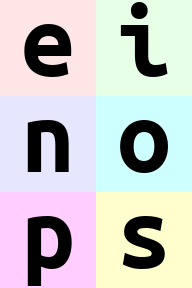

In [165]:
# YOUR CODE HERE

rearrange(ims, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=3)

<details><summary>Answer</summary>

```python
rearrange(ims, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=3)
```
</details>

### Exercise 3.2
Split each image's width in half and interleave the halves into the height dimension.

Take the full batch `ims` and produce shape `(192, 48, 3)` — images stacked vertically, each with its width halved and height doubled.

Hint: Decompose `w` into `(w1 w2)` with `w2=2`. Move `w2` next to `h` during composition. Compose `b` with `w1` for the width.

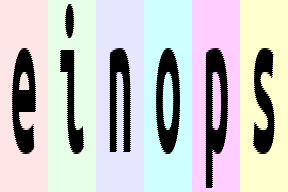

In [166]:
# Target shape: (192, 48, 3)
# YOUR CODE HERE
rearrange(ims, 'b h (w1 w2) c -> (h w2) (b w1) c', w2=2)

<details><summary>Hint</summary>

Pattern: `'b h (w1 w2) c -> (h w2) (b w1) c'` with `w2=2`
</details>

<details><summary>Answer</summary>

```python
rearrange(ims, 'b h (w1 w2) c -> (h w2) (b w1) c', w2=2)
```
</details>

### Exercise 3.3
Take a single image `ims[0]` of shape `(96, 96, 3)` and split it into a **2×2 grid of patches**, producing shape `(2, 2, 48, 48, 3)`.

Hint: Decompose both `h` and `w` into two parts each. The outer parts become the grid indices, the inner parts become the patch dimensions.

In [169]:
# Target shape: (2, 2, 48, 48, 3)
# YOUR CODE HERE

rearrange(ims[0], '(h1 h2) (w1 w2) c -> h1 w1 h2 w2 c', h1=2, w1=2)

<array of shape (2, 2, 48, 48, 3)>


---
## Section 4: Reduce — Basic Reductions

`reduce` works like `rearrange` but **removes axes** by aggregating over them. Any axis on the left that does not appear on the right is reduced using the specified operation (`'mean'`, `'max'`, `'min'`, `'sum'`, `'prod'`).

For example, `reduce(ims, 'b h w c -> h w c', 'mean')` averages over the batch axis `b`, producing a single "mean image" from all 6.

### Worked Example

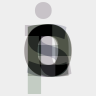

In [90]:
# Average all 6 images into one by reducing over the batch axis
# (6, 96, 96, 3) -> (96, 96, 3)
reduce(ims, 'b h w c -> h w c', 'mean')

### Exercise 4.1
Compute the **max** across all 6 images — same spatial pattern, but take the maximum instead of the mean.

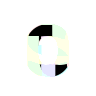

In [91]:
# YOUR CODE HERE
reduce(ims, 'b h w c -> h w c', 'max')

<details><summary>Answer</summary>

```python
reduce(ims, 'b h w c -> h w c', 'max')
```
</details>

### Exercise 4.2
**Mean-pool** each image with a 2×2 kernel, then display all 6 side by side at half resolution.

Target shape: `(48, 288, 3)`.

Hint: Decompose `h` into `(h h2)` and `w` into `(w w2)` with `h2=2, w2=2`. Reduce (mean) over `h2` and `w2`. Compose `b` into `w` to display side by side.

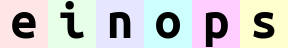

In [107]:
# Target shape: (48, 288, 3)
# YOUR CODE HERE
reduce(ims, 'b (h h2) (w w2) c -> h (b w) c', 'mean', h2=2, w2=2)

# writing -> (b w) h c would be taking the transpose of the matrix as-is

<details><summary>Answer</summary>

```python
reduce(ims, 'b (h h2) (w w2) c -> h (b w) c', 'mean', h2=2, w2=2)
```
</details>

### Exercise 4.3
Compute a **single mean color value** per image — the result should have shape `(6, 3)`, one RGB triplet per image.

In [110]:
# Target shape: (6, 3)
# YOUR CODE HERE

reduce(ims, 'b h w c -> b c', 'mean')

<details><summary>Answer</summary>

```python
reduce(ims, 'b h w c -> b c', 'mean')
```
</details>

---
## Section 5: Repeat — Repeating Elements

`repeat` is the inverse of `reduce`: it **adds** elements by duplicating along axes. You can repeat along new axes or expand existing ones.

For example, `repeat(ims[0], 'h w c -> (2 h) (2 w) c')` doubles both height and width by repeating each pixel in a 2×2 block — nearest-neighbor 2× upscaling.

### Worked Example

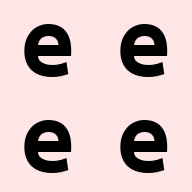

In [111]:
# 2x nearest-neighbor upscale of one image
# (96, 96, 3) -> (192, 192, 3)
repeat(ims[0], 'h w c -> (2 h) (2 w) c')

### Exercise 5.1
**3× upscale** a single image (`ims[0]`) using nearest-neighbor repetition. Output shape should be `(288, 288, 3)`.

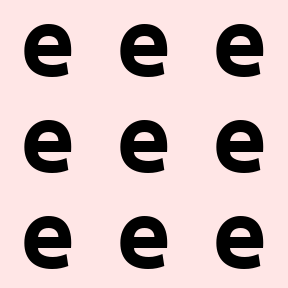

In [119]:
# YOUR CODE HERE
repeat(ims[0], 'h w c -> (3 h) (3 w) c')

<details><summary>Answer</summary>

```python
repeat(ims[0], 'h w c -> (3 h) (3 w) c')
```
</details>

### Exercise 5.2
Repeat each pixel column **3 times** along the width for `ims[0]`. Each column of pixels should appear 3 times consecutively. Output shape: `(96, 288, 3)`.

Hint: Use a named repeat axis composed with `w`.

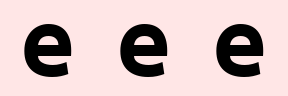

In [127]:
# YOUR CODE HERE
repeat(ims[0], 'h w c -> h (3 w) c')

<details><summary>Answer</summary>

```python
repeat(ims[0], 'h w c -> h (w repeat) c', repeat=3)
```
</details>

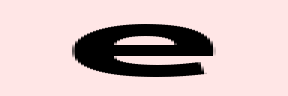

In [128]:
repeat(ims[0], 'h w c -> h (w repeat) c', repeat=3)

### Exercise 5.3
**Pixelation effect**: Take `ims[0]`, downscale with a 4×4 mean pool using `reduce`, then upscale back to the original size with `repeat` (4×4). This is a two-step exercise.

Step 1: `reduce` to shape `(24, 24, 3)` 
Step 2: `repeat` back to shape `(96, 96, 3)`

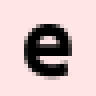

In [135]:
# Step 1: downscale with 4x4 mean pool
# YOUR CODE HERE
# downscaled = ...

shrunken = reduce(ims[0],'(h h2) (w w2) c -> h w c', 'mean', h2=4, w2=4)

# Step 2: upscale back to original size
# YOUR CODE HERE
# pixelated = ...

scaled = repeat(shrunken, 'h w c -> (h 4) (w 4) c') 

# pixelated

scaled

<details><summary>Answer</summary>

```python
downscaled = reduce(ims[0], '(h h2) (w w2) c -> h w c', 'mean', h2=4, w2=4)
pixelated = repeat(downscaled, 'h w c -> (h 4) (w 4) c')
pixelated
```
</details>

---
## Section 6: Combining Operations — Challenge Exercises

These exercises combine multiple einops operations. They are harder and more open-ended.

### Exercise 6.1
**Normalize each image** to the [0, 1] range individually. For each image, subtract its min value and divide by (max - min).

Hint: Use `reduce` with `'b h w c -> b () () ()'` to compute per-image min/max while keeping dimensions compatible for broadcasting. Use `'min'` and `'max'` reductions.

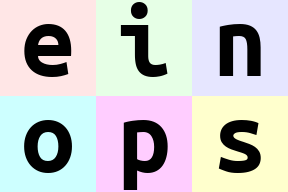

In [149]:
# Compute per-image min and max, then normalize
# YOUR CODE HERE
# ims_min = reduce(ims, ...)
# ims_max = reduce(ims, ...)
# normalized = (ims - ims_min) / (ims_max - ims_min)

# Display as a grid to verify
# rearrange(normalized, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)

max_arr = reduce(ims, 'b h w c -> b () () ()', 'max')
min_arr = reduce(ims, 'b h w c -> b () () ()', 'min')
normalized = (ims - min_arr) / (max_arr - min_arr)

rearrange(normalized, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)

<details><summary>Answer</summary>

```python
ims_min = reduce(ims, 'b h w c -> b () () ()', 'min')
ims_max = reduce(ims, 'b h w c -> b () () ()', 'max')
normalized = (ims - ims_min) / (ims_max - ims_min)
rearrange(normalized, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)
```
</details>

### Exercise 6.2
Create a **contact sheet**: a 2×3 grid of images, each downscaled 2× via mean pooling.

Final shape: `(96, 144, 3)` — two rows of three images, each 48×48.

Hint: You can do this in a single `reduce` call by combining decomposition of `b` and `h`/`w` in the same pattern.

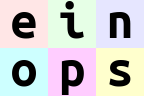

In [153]:
# YOUR CODE HERE

reduce(ims, '(b b1) (h h2) (w w2) c -> (b h) (b1 w) c', 'mean', b1=3, h2=2, w2=2)

<details><summary>Hint</summary>

Pattern: `'(b1 b2) (h h2) (w w2) c -> (b1 h) (b2 w) c'` with `b1=2, h2=2, w2=2`, reduction `'mean'`
</details>

<details><summary>Answer</summary>

```python
reduce(ims, '(b1 b2) (h h2) (w w2) c -> (b1 h) (b2 w) c', 'mean', b1=2, h2=2, w2=2)
```
</details>

### Exercise 6.3
**Convert to grayscale and back**: Take `ims[0]`, average over the color channel to get a grayscale image, then repeat that single channel back to 3 channels so it displays as a gray image.

Step 1: `reduce` over `c` to get shape `(96, 96)` or `(96, 96, 1)` 
Step 2: `repeat` the channel axis to get shape `(96, 96, 3)`

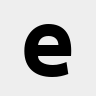

In [164]:
# Step 1: average over color channels
# YOUR CODE HERE
# grayscale = ...

grayscale = reduce(ims[0], 'h w c -> h w', 'mean')

# Step 2: repeat back to 3 channels
# YOUR CODE HERE
# gray_rgb = ...


# gray_rgb

gray_rgb = repeat(grayscale, 'h w -> h w 3')ra
gray_rgb

<details><summary>Answer</summary>

```python
grayscale = reduce(ims[0], 'h w c -> h w', 'mean')
gray_rgb = repeat(grayscale, 'h w -> h w c', c=3)
gray_rgb
```
</details>

---

## Summary

- **`rearrange`** reorders and reshapes without changing the number of elements. Compose axes with `()` on the right, decompose with `()` on the left.
- **`reduce`** removes axes by aggregating (mean, max, min, sum, prod). Axes on the left but not on the right are reduced.
- **`repeat`** adds elements by duplicating along new or existing axes — the inverse of reduce.

For more, see the [einops documentation](https://einops.rocks/) and the solutions notebook at `solutions/1-einops-basics.ipynb`.